In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from time import time

In [79]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import RidgeClassifier, LogisticRegression, LinearRegression
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay, root_mean_squared_error, silhouette_score
from sklearn.decomposition import PCA

# Классификация

## Набор данных

В работе рассматривается соревнование Kaggle [Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic) на основе датасета, содержащего персональные данные 8700 пассажиров попашего в пространственную аномалию межпланетного лайнера «Титаник». Данные представлены в следующем формате:

1. **PassengerId** — Уникальный идентификатор для каждого пассажира. Имеет формат `gggg_pp`, где `gggg` обозначает группу, с которой путешествует пассажир, а `pp` — его номер в группе. Люди в группе часто являются членами семьи, но не всегда.
2. **HomePlanet** — Планета, с которой отправился пассажир, обычно это планета его постоянного проживания.
3. **CryoSleep** — Указывает, выбрал ли пассажир состояние анабиоза на время путешествия. Пассажиры в криосне находятся в своих каютах.
4. **Cabin** — Номер каюты, в которой проживает пассажир. Имеет формат `палуба/номер/сторона`, где сторона может быть:
    - `P` (Порт, левый борт),
    - `S` (Старборд, правый борт).
5. **Destination** — Планета, на которой пассажир сойдет (деборкируется).
6. **Age** — Возраст пассажира.
7. **VIP** — Имел ли пассажир доступ к специальному VIP-обслуживанию во время полета.
8. **RoomService, FoodCourt, ShoppingMall, Spa, VRDeck** — Сумма, которую пассажир потратил в каждом из перечисленных объектов роскоши на корабле «Титаник».
9. **Name** — Имя и фамилия пассажира.
10. **Transported** — Был ли пассажир перемещен в другое измерение; целевая переменная.

In [30]:
tit_train = pd.read_csv("dataset_titanic/train.csv")
tit_test =  pd.read_csv("dataset_titanic/test.csv")

tit_train.head(5)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [31]:
tit_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [32]:
tit_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


In [33]:
def preprocess_titanic(tit_df: pd.DataFrame):
    tit_df.drop(columns=["Name"], inplace=True)

    num_columns = tit_df.select_dtypes(include=np.number).columns.drop("Age")
    for column in num_columns:
        tit_df.fillna({column: 0}, inplace=True)

    tit_df.dropna(inplace=True)

    tit_df["CryoSleep"] = tit_df["CryoSleep"].astype(bool)
    tit_df["VIP"] = tit_df["VIP"].astype(bool)

    tit_df["Group"] = tit_df["PassengerId"].str.split("_").str[0].astype(int)
    tit_df["GroupNum"] = tit_df["PassengerId"].str.split("_").str[1].astype(int)
    tit_df.drop(columns=["PassengerId"], inplace=True)

    tit_df["CabinDeck"] = tit_df["Cabin"].str.split("/").str[0]
    tit_df["CabinNumber"] = tit_df["Cabin"].str.split("/").str[1].astype(int)
    tit_df["CabinSide"] = tit_df["Cabin"].str.split("/").str[2]
    tit_df.drop(columns=["Cabin"], inplace=True)

    return tit_df

In [34]:
## FOR FUTURE IMPROVEMENT - FILLING NANS INSTEAD OF DROPPING   
# tit_df = fill_nans_titanic(tit_df)

# def fill_nans_titanic(tit_df: pd.DataFrame):
#     for column in ["HomePlanet", "CryoSleep", "Destination"]:
#         tit_df[column] = tit_df[column].fillna(tit_df[column].mode()[0])
    
#     tit_df["CabinDeck"] = tit_df["Cabin"].
    
    
#     tit_df["Age"] = tit_df["Age"].fillna(tit_df["Age"].median())

#     num_columns = tit_df.select_dtypes(include=np.number).columns.drop("Age")
#     for column in num_columns:
#         tit_df[column] = tit_df[column].where(~tit_df["CryoSleep"], 0)

#     tit_df

In [35]:
tit_train = preprocess_titanic(tit_train)
tit_test = preprocess_titanic(tit_test)

tit_train.head(5)

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Group,GroupNum,CabinDeck,CabinNumber,CabinSide
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,1,1,B,0,P
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,2,1,F,0,S
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,3,1,A,0,S
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,3,2,A,0,S
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,4,1,F,1,S


In [36]:
tit_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7572 entries, 0 to 8692
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    7572 non-null   object 
 1   CryoSleep     7572 non-null   bool   
 2   Destination   7572 non-null   object 
 3   Age           7572 non-null   float64
 4   VIP           7572 non-null   bool   
 5   RoomService   7572 non-null   float64
 6   FoodCourt     7572 non-null   float64
 7   ShoppingMall  7572 non-null   float64
 8   Spa           7572 non-null   float64
 9   VRDeck        7572 non-null   float64
 10  Transported   7572 non-null   bool   
 11  Group         7572 non-null   int64  
 12  GroupNum      7572 non-null   int64  
 13  CabinDeck     7572 non-null   object 
 14  CabinNumber   7572 non-null   int64  
 15  CabinSide     7572 non-null   object 
dtypes: bool(3), float64(6), int64(3), object(4)
memory usage: 850.4+ KB


In [37]:
tit_train_X = tit_train.drop(columns=["Transported"])
tit_train_y = tit_train["Transported"]

In [38]:
tit_train_X_enc = pd.get_dummies(tit_train_X)
tit_test_enc = pd.get_dummies(tit_test)
tit_train_X_enc.columns

Index(['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall',
       'Spa', 'VRDeck', 'Group', 'GroupNum', 'CabinNumber', 'HomePlanet_Earth',
       'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e',
       'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'CabinDeck_A',
       'CabinDeck_B', 'CabinDeck_C', 'CabinDeck_D', 'CabinDeck_E',
       'CabinDeck_F', 'CabinDeck_G', 'CabinDeck_T', 'CabinSide_P',
       'CabinSide_S'],
      dtype='object')

In [39]:
tit_train_X_enc.head(5)

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Group,GroupNum,...,CabinDeck_A,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinSide_P,CabinSide_S
0,False,39.0,False,0.0,0.0,0.0,0.0,0.0,1,1,...,False,True,False,False,False,False,False,False,True,False
1,False,24.0,False,109.0,9.0,25.0,549.0,44.0,2,1,...,False,False,False,False,False,True,False,False,False,True
2,False,58.0,True,43.0,3576.0,0.0,6715.0,49.0,3,1,...,True,False,False,False,False,False,False,False,False,True
3,False,33.0,False,0.0,1283.0,371.0,3329.0,193.0,3,2,...,True,False,False,False,False,False,False,False,False,True
4,False,16.0,False,303.0,70.0,151.0,565.0,2.0,4,1,...,False,False,False,False,False,True,False,False,False,True


In [40]:
std_scaler = StandardScaler()
tit_train_X_scaled = pd.DataFrame(
    std_scaler.fit_transform(tit_train_X_enc),
    index=tit_train_X_enc.index,
    columns=tit_train_X_enc.columns
)
tit_test_scaled = pd.DataFrame(
    std_scaler.transform(tit_test_enc),
    index=tit_test_enc.index,
    columns=tit_test_enc.columns
)

## Обучение моделей

Далее используются модели:
- линейная и логистическая регрессии;
- SVM с линейным и гауссовским ядрами;
- KNN; 
- решающие деревья.

В качестве метрики классификации используются accuracy (метрика соревнования) и AUC_ROC.

In [41]:
seed = 42
classifiers = {
    "Linear classifier":  RidgeClassifier(max_iter=1000, random_state=seed),
    "Logistic regressor": LogisticRegression(max_iter=1000, random_state=seed),
    "SVM linear":         SVC(kernel="linear", probability=True, random_state=seed),
    "SVM":                SVC(probability=True, random_state=seed),
    "KNN":                KNeighborsClassifier(n_neighbors=6),
    "Decision tree":      DecisionTreeClassifier(max_depth=5, random_state=seed)
}

In [42]:
def evaluate_model_class(model, has_prob: bool, X_train, y_train, X_test, y_test):
    time_beg = time()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_conf = model.predict_proba(X_test) if has_prob else model.decision_function(X_test)

    time_end = time()
    
    return {
        "Predictions": y_pred, 
        "Confidence":  y_pred_conf,
        "Accuracy":    accuracy_score(y_test, y_pred), 
        "AUC-ROC":     roc_auc_score(y_test, y_pred_conf[:, 1]) if has_prob else roc_auc_score(y_test, y_pred_conf),
        "Time":        time_end - time_beg  
    }

Linear classifier metrics:
    Accuracy: 0.7603960396039604
    AUC-ROC:  0.8427113763604293
    Time:     0.008991718292236328
Logistic regressor metrics:
    Accuracy: 0.7643564356435644
    AUC-ROC:  0.8694144838212635
    Time:     0.024001121520996094
SVM linear metrics:
    Accuracy: 0.7716171617161716
    AUC-ROC:  0.868204826081197
    Time:     8.817990779876709
SVM metrics:
    Accuracy: 0.7881188118811882
    AUC-ROC:  0.8678353052729922
    Time:     11.357803583145142
KNN metrics:
    Accuracy: 0.7702970297029703
    AUC-ROC:  0.8541734935054974
    Time:     0.05029153823852539
Decision tree metrics:
    Accuracy: 0.7557755775577558
    AUC-ROC:  0.846647993083686
    Time:     0.028698444366455078


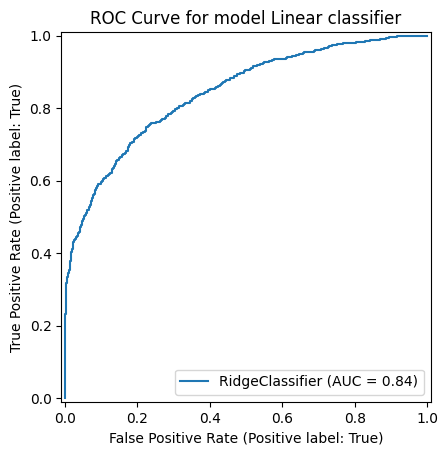

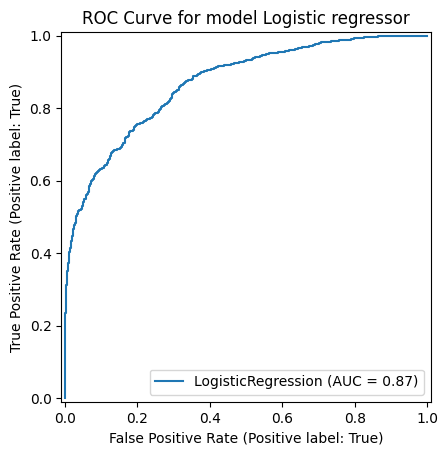

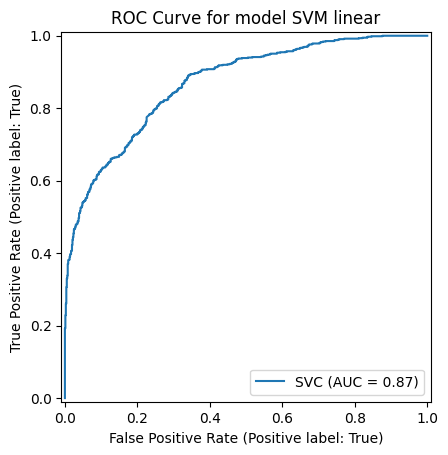

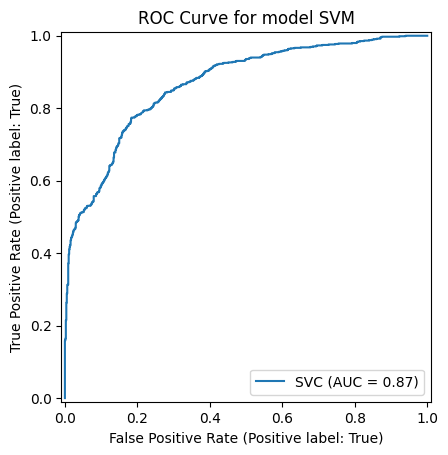

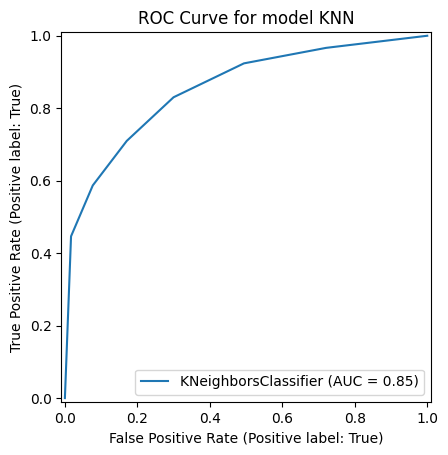

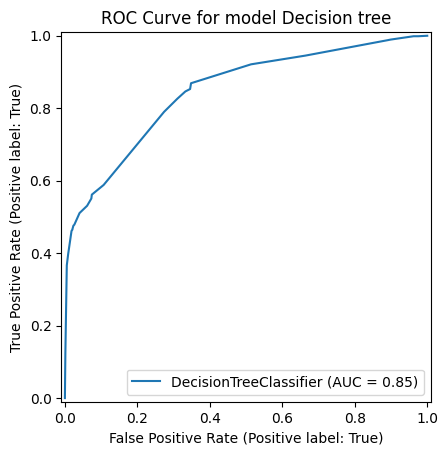

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(tit_train_X_scaled, tit_train_y, test_size=0.2, random_state=seed)

results_class = {}

for name, model in classifiers.items():
    results_class[name] = evaluate_model_class(
        model, 
        (name != "Linear classifier"),
        X_train, y_train, 
        X_val, y_val
    )
    print(f"{name} metrics:")
    for metric in ["Accuracy", "AUC-ROC", "Time"]:
        print(f"    {metric}:", results_class[name][metric])

for name, model in classifiers.items():
    RocCurveDisplay.from_estimator(model, X_val, y_val)
    plt.title(f'ROC Curve for model {name}')
    plt.show()

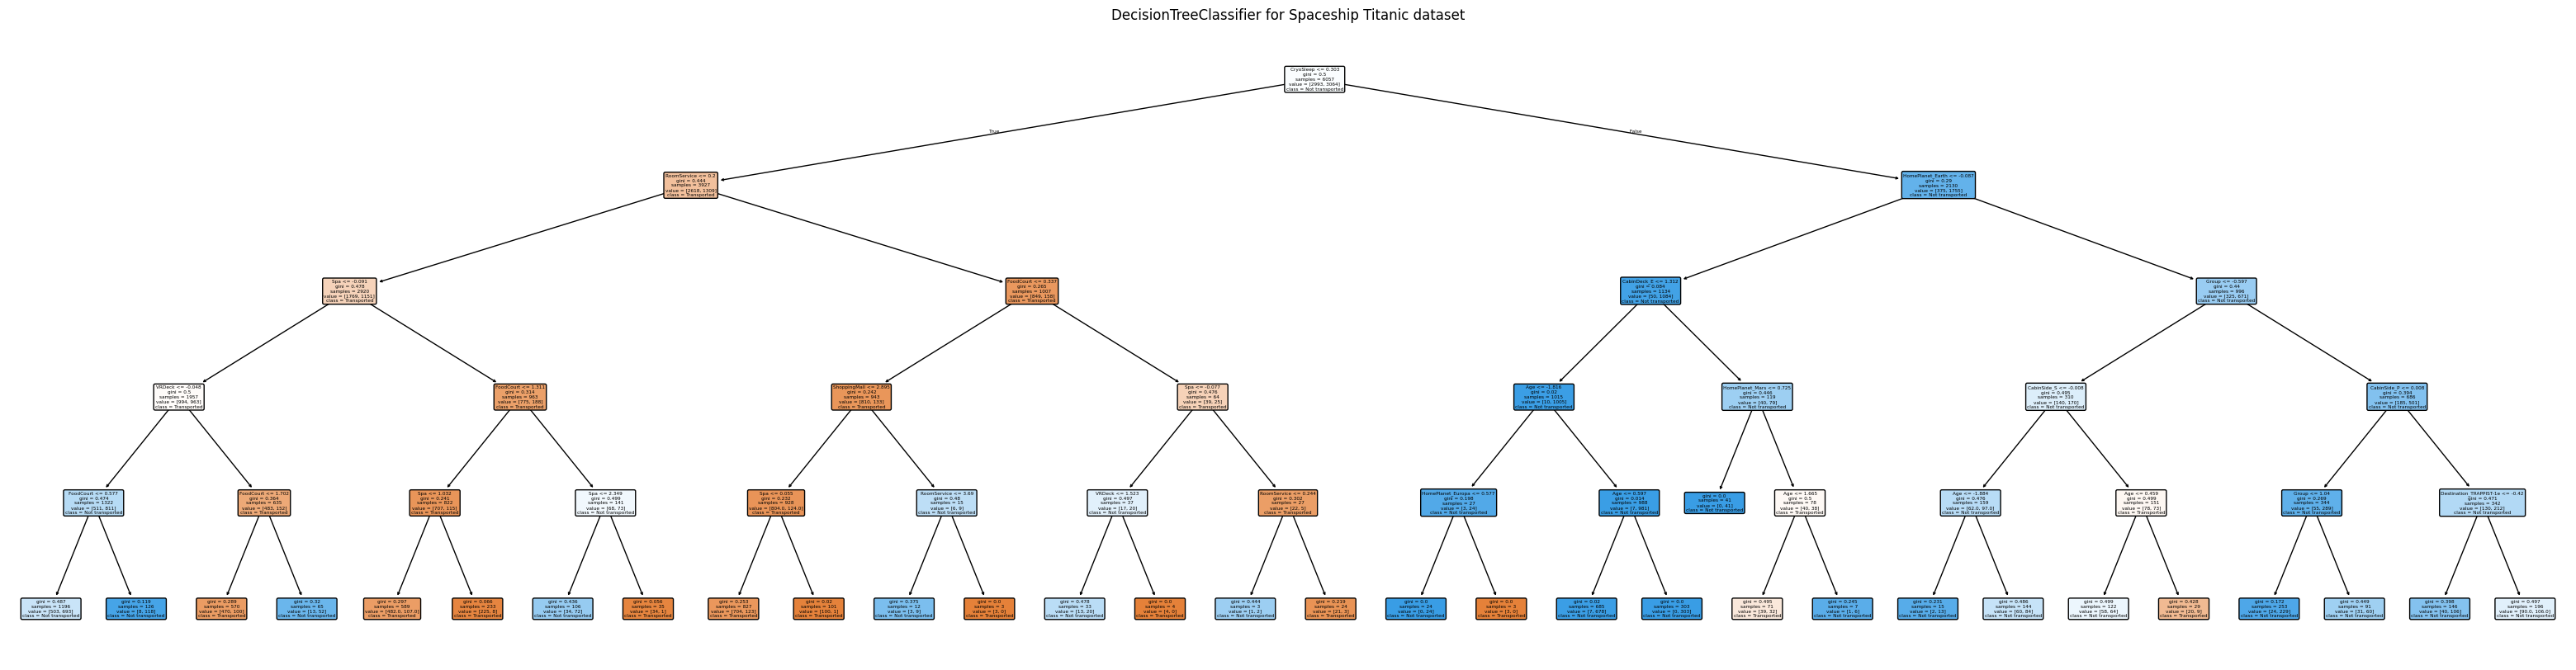

In [44]:
plt.figure(figsize=(40, 10))

plot_tree(
    classifiers["Decision tree"],
    feature_names=X_train.columns,
    class_names=["Transported", "Not transported"],
    filled=True,
    rounded=True
)

plt.title("DecisionTreeClassifier for Spaceship Titanic dataset")
plt.show()

## Топ моделей

In [45]:
best_models_metrics = {
    metric: max(
        ((model_name, metrics[metric]) for model_name, metrics in results_class.items()),
        key=lambda x: x[1]
    )
    for metric in ["Accuracy", "AUC-ROC"]
}
best_model_time = min(
    ((model_name, metrics["Time"]) for model_name, metrics in results_class.items()),
    key=lambda x: x[1]
)

print("Models with best metrics:")
for metric, (model_name, value) in best_models_metrics.items():
    print(f"    {metric} - {model_name} ({value:.4f}), time = {results_class[model_name]['Time']:.4f} s")

Models with best metrics:
    Accuracy - SVM (0.7881), time = 11.3578 s
    AUC-ROC - Logistic regressor (0.8694), time = 0.0240 s


# Регрессия

## Набор данных

В работе рассматривается соревнование Kaggle [Predicting the Beats-per-Minute of Songs](https://www.kaggle.com/competitions/playground-series-s5e9) на основе датасета, сгенерированного из набора параметров музыкальных записей [BPM Prediction Challenge](). Данные представлены в следующем формате*:


1.  **RhythmScore** — Оценка выраженности ритмического рисунка трека.
2.  **AudioLoudness** — Уровень громкости (громкозвучания) аудиозаписи.
3.  **VocalContent** — Присутствие и количество вокала в треке.
4.  **AcousticQuality** — Оценка акустического качества (в противоположность электронному).
5.  **InstrumentalScore** — Оценка инструментального наполнения.
6.  **LivePerformanceLikelihood** — Вероятность факта записи трека во время живого выступления.
7.  **MoodScore** — Оценка настроения трека.
8.  **TrackDurationMs** — Длительность трека в миллисекундах (мс).
9.  **Energy** — Оценка энергичности и интенсивности звучания трека.
10. **BeatsPerMinute (BPM)** — Темп трека, количество битов в минуту; целевой признак.

*(\*) интерпретации признаков являются ручной редакцией генерации DeepSeek ввиду отсутствия описания в оригинальном источнике*

In [46]:
bpm_train = pd.read_csv("dataset_bpm/train.csv", index_col=0)
bpm_test =  pd.read_csv("dataset_bpm/test.csv", index_col=0)

bpm_train.head(5)

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
id,,,,,,,,,,
0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [47]:
bpm_train.describe()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
count,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000
mean,0.632843,-8.379014,0.074443,0.262913,0.117690,0.178398,0.555843,241903.692949,0.500923,119.034899
std,0.156899,4.616221,0.049939,0.223120,0.131845,0.118186,0.225480,59326.601501,0.289952,26.468077
min,0.076900,-27.509725,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000067,46.718000
25%,0.515850,-11.551933,0.023500,0.069413,0.000001,0.077637,0.403921,207099.876625,0.254933,101.070410
50%,0.634686,-8.252499,0.066425,0.242502,0.074247,0.166327,0.564817,243684.058150,0.511800,118.747660
75%,0.739179,-4.912298,0.107343,0.396957,0.204065,0.268946,0.716633,281851.658500,0.746000,136.686590
max,0.975000,-1.357000,0.256401,0.995000,0.869258,0.599924,0.978000,464723.228100,1.000000,206.037000


In [48]:
bpm_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 524164 entries, 0 to 524163
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   RhythmScore                524164 non-null  float64
 1   AudioLoudness              524164 non-null  float64
 2   VocalContent               524164 non-null  float64
 3   AcousticQuality            524164 non-null  float64
 4   InstrumentalScore          524164 non-null  float64
 5   LivePerformanceLikelihood  524164 non-null  float64
 6   MoodScore                  524164 non-null  float64
 7   TrackDurationMs            524164 non-null  float64
 8   Energy                     524164 non-null  float64
 9   BeatsPerMinute             524164 non-null  float64
dtypes: float64(10)
memory usage: 44.0 MB


In [49]:
bpm_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 174722 entries, 524164 to 698885
Data columns (total 9 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   RhythmScore                174722 non-null  float64
 1   AudioLoudness              174722 non-null  float64
 2   VocalContent               174722 non-null  float64
 3   AcousticQuality            174722 non-null  float64
 4   InstrumentalScore          174722 non-null  float64
 5   LivePerformanceLikelihood  174722 non-null  float64
 6   MoodScore                  174722 non-null  float64
 7   TrackDurationMs            174722 non-null  float64
 8   Energy                     174722 non-null  float64
dtypes: float64(9)
memory usage: 13.3 MB


In [50]:
bpm_train_X = bpm_train.drop(columns=["BeatsPerMinute"])
bpm_train_y = bpm_train["BeatsPerMinute"]

In [51]:
std_scaler = StandardScaler()
bpm_train_X_scaled = pd.DataFrame(
    std_scaler.fit_transform(bpm_train_X),
    index=bpm_train_X.index,
    columns=bpm_train_X.columns
)
bpm_test_scaled = pd.DataFrame(
    std_scaler.transform(bpm_test),
    index=bpm_test.index,
    columns=bpm_test.columns
)
bpm_train_X_scaled.describe()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy
count,5.241640e+05,5.241640e+05,5.241640e+05,5.241640e+05,5.241640e+05,5.241640e+05,5.241640e+05,5.241640e+05,5.241640e+05
mean,9.138191e-16,-2.552273e-16,-2.082161e-17,1.773632e-16,1.355573e-17,-6.398306e-18,2.813086e-16,1.946603e-17,1.084459e-17
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-3.543318e+00,-4.144240e+00,-1.020114e+00,-1.178322e+00,-8.926359e-01,-1.303869e+00,-2.351620e+00,-2.999175e+00,-1.727375e+00
25%,-7.456619e-01,-6.873418e-01,-1.020114e+00,-8.672440e-01,-8.926359e-01,-8.525686e-01,-6.737735e-01,-5.866483e-01,-8.483792e-01
50%,1.174725e-02,2.740671e-02,-1.605663e-01,-9.147857e-02,-3.295000e-01,-1.021412e-01,3.979920e-02,3.000959e-02,3.751458e-02
75%,6.777355e-01,7.509864e-01,6.588087e-01,6.007710e-01,6.551296e-01,7.661505e-01,7.130984e-01,6.733574e-01,8.452345e-01
max,2.180745e+00,1.521162e+00,3.643643e+00,3.281138e+00,5.700409e+00,3.566645e+00,1.872258e+00,3.755815e+00,1.721241e+00


## Обучение моделей

Далее используются модели:
- линейная регрессия;
- SVM с линейным и гауссовским ядрами;
- KNN; 
- решающие деревья.

В качестве метрики регрессии используется RMSE.

In [52]:
seed = 42
regressors = {
    "Linear regression":   LinearRegression(),
    "Decision tree":       DecisionTreeRegressor(max_depth=5, random_state=seed),
    "SVM linear":          SVR(kernel="linear"),
    "SVM":                 SVR(),
    "KNN":                 KNeighborsRegressor(n_neighbors=3)
}

In [53]:
def evaluate_model_regr(model, X_train, y_train, X_test, y_test):
    time_beg = time()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    time_end = time()
    
    return {
        "Predictions": y_pred, 
        "RMSE":        root_mean_squared_error(y_test, y_pred),
        "Time":        time_end - time_beg
    }

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(bpm_train_X_scaled, bpm_train_y, test_size=0.2, random_state=seed)

results_regr = {}
for name, model in regressors.items():
    results_regr[name] = evaluate_model_regr(model, X_train, y_train, X_val, y_val)
    print(f"{name} metrics:")
    for metric in ["RMSE", "Time"]:
        print(f"    {metric}:", results_regr[name][metric])

Linear regression metrics:
    RMSE: 26.443879848299765
    Time: 0.1080782413482666


## Топ моделей

In [ ]:
best_model = min(
        ((model_name, metrics["RMSE"]) for model_name, metrics in results_regr.items()),
        key=lambda x: x[1]
    )

print(f"Model with best RMSE: {best_model[0]} ({value:.4f}), time = {results_regr[best_model[0]]['Time']:.4f} s")

# Кластеризация

## Набор данных

В работе рассматривается соревнование Kaggle [Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic) из раздела "Классификация" выше.

## Обучение моделей

Далее используются модели кластеризации:
- K-Means, 
- иерархическая, 
- GMM.

Будем делить данные на 2 кластера для сведения к задаче классификации. В качестве метрики классификации используются accuracy (метрика соревнования).

In [72]:
seed = 42
n_clusters = 2

clusterizers = {
    "K-Means":      KMeans(n_clusters=n_clusters, random_state=seed),
    "Hierarchical": AgglomerativeClustering(n_clusters=n_clusters),
    "GMM":          GaussianMixture(n_components=n_clusters, random_state=seed),
}

In [73]:
def evaluate_model_clust(model, X_train, y_train):
    time_beg = time()

    y_pred = model.fit_predict(X_train)
    
    time_end = time()
    
    return {
        "Predictions": y_pred, 
        "Accuracy":    accuracy_score(y_train, y_pred),
        "Silhouette":  silhouette_score(X_train, y_pred),
        "Time":        time_end - time_beg
    }

In [74]:
X_train, y_train = tit_train_X_scaled, tit_train_y

results_clust = {}
for name, model in clusterizers.items():
    results_clust[name] = evaluate_model_clust(model, X_train, y_train)
    print(f"{name} clusterization metrics:")
    for metric in ["Accuracy", "Silhouette", "Time"]:
        print(f"    {metric}:", results_clust[name][metric])

K-Means clusterization metrics:
    Accuracy: 0.5760697305863708
    Silhouette: 0.22915825165860643
    Time: 0.015648365020751953
Hierarchical clusterization metrics:
    Accuracy: 0.5625990491283677
    Silhouette: 0.2295075107077672
    Time: 2.3364806175231934
GMM clusterization metrics:
    Accuracy: 0.5762017960908611
    Silhouette: 0.2291668980809573
    Time: 0.057991981506347656


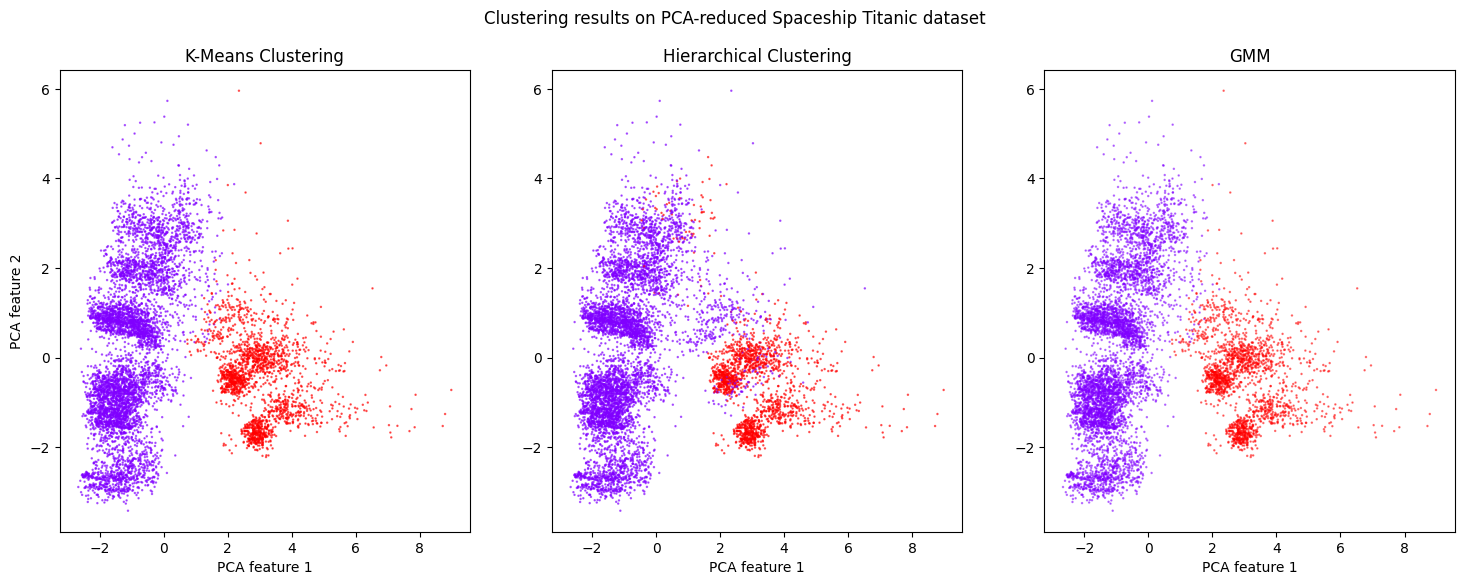

In [96]:
X_train_red = PCA(n_components=2).fit_transform(X_train)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(
    X_train_red[:, 0], 
    X_train_red[:, 1], 
    c=results_clust["K-Means"]["Predictions"], 
    cmap="rainbow",
    s=0.6,
    alpha=0.6
)
axes[0].set_title("K-Means Clustering")
axes[0].set_ylabel("PCA feature 2")

axes[1].scatter(
    X_train_red[:, 0], 
    X_train_red[:, 1], 
    c=results_clust["Hierarchical"]["Predictions"], 
    cmap="rainbow",
    s=0.6,
    alpha=0.6
)
axes[1].set_title("Hierarchical Clustering")

axes[2].scatter(
    X_train_red[:, 0], 
    X_train_red[:, 1], 
    c=results_clust["GMM"]["Predictions"], 
    cmap="rainbow",
    s=0.6,
    alpha=0.5
)
axes[2].set_title("GMM")

for ax in axes:
    ax.set_xlabel("PCA feature 1")
fig.suptitle("Clustering results on PCA-reduced Spaceship Titanic dataset")
plt.show()

## Топ моделей

In [100]:
best_models_metrics = {
    metric: max(
        ((model, metrics[metric]) for model, metrics in results_clust.items()),
        key=lambda x: x[1]
    )
    for metric in ["Accuracy", "Silhouette"]
}
best_model_time = min(
    ((model, metrics["Time"]) for model, metrics in results_clust.items()),
    key=lambda x: x[1]
)

print("Models with best metrics:")
for metric, (model_name, value) in best_models_metrics.items():
    print(f"    {metric} - {model_name} ({value:.4f}), time = {results_clust[model_name]['Time']:.4f} s")

Models with best metrics:
    Accuracy - GMM (0.5762), time = 0.0580 s
    Silhouette - Hierarchical (0.2295), time = 2.3365 s
